In [56]:
from eddy import rotationmap
import bettermoments as bm
from astropy.io import fits
from spectral_cube import SpectralCube
import astropy.units as u
import numpy as np
import matplotlib.pyplot as plt
from astropy.nddata import Cutout2D
from matplotlib_scalebar.scalebar import ScaleBar
from mpl_toolkits.axes_grid1.anchored_artists import AnchoredSizeBar
from photutils import aperture

import matplotlib.font_manager as fm

## ALMA Gas Line Data

##### <span style="color:red">REMEMBER: </span> ALMA images have an inverted x axis! Left to right --> + to -

You will notice that when plotting images in this section I always invert the x axis

In [9]:
#Using spectral_cube to read ALMA CO linecube

ALMAData = fits.open('NewALMAData/AT_Pyx_CO_selfcal_30s.contsub.cvel.image.fits')
cube = SpectralCube.read(ALMAData)
print(cube)

VaryingResolutionSpectralCube with shape=(14, 1024, 1024) and unit=Jy / beam:
 n_x:   1024  type_x: RA---SIN  unit_x: deg    range:   127.160984 deg:  127.178078 deg
 n_y:   1024  type_y: DEC--SIN  unit_y: deg    range:   -33.779886 deg:  -33.765677 deg
 n_s:     14  type_s: FREQ      unit_s: Hz     range: 230530151562.400 Hz:230536649150.141 Hz


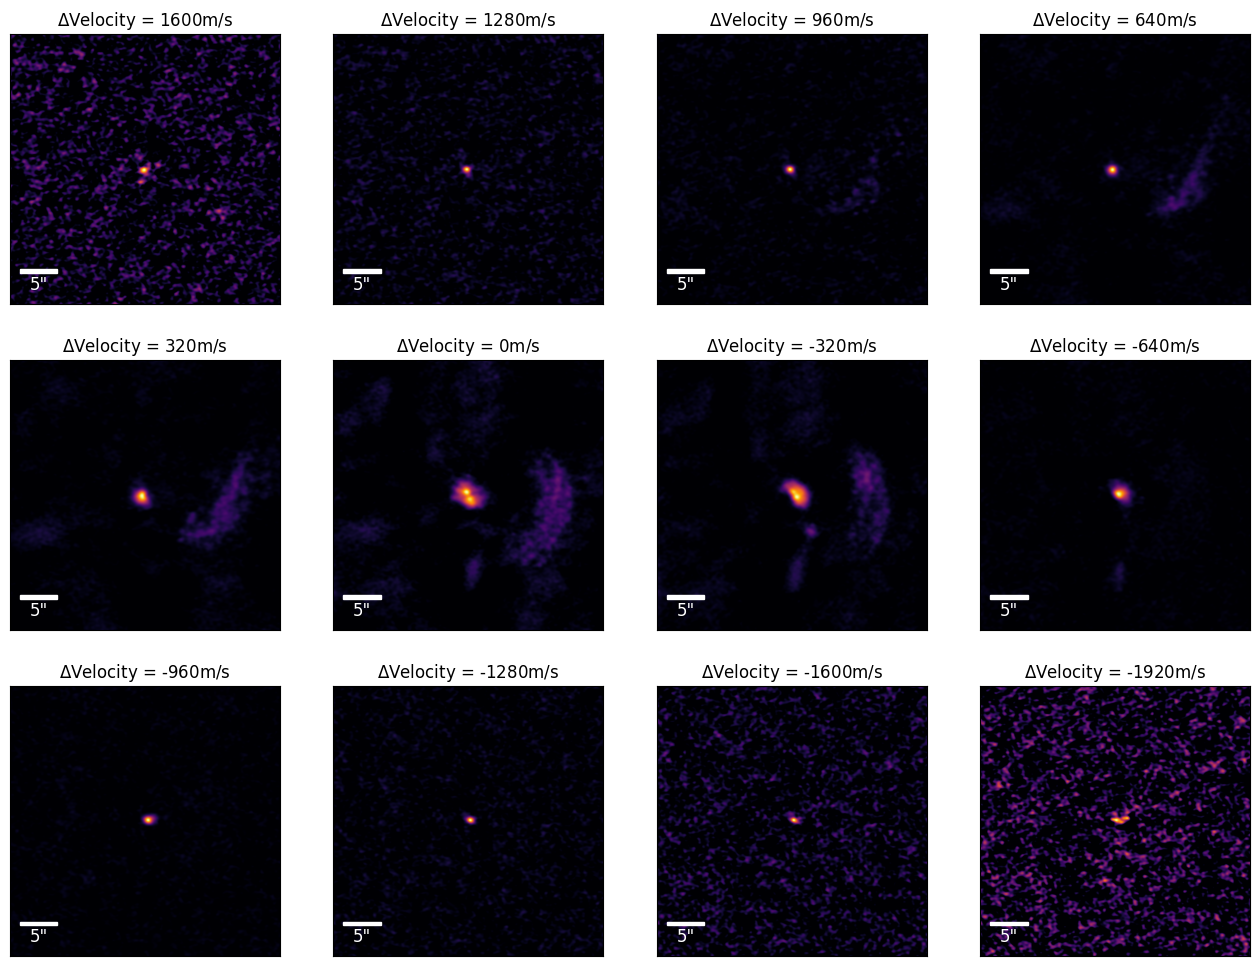

In [11]:
#Make a subcube over spectral range in which source is present

sub_cube_slab = cube.spectral_slab(2.3053e+11 *u.Hz, 2.30536e+11 *u.Hz)



#convert to numpy array
subcubearray = np.array(sub_cube_slab)


#Some nastiness for plotting all the images in this range

m=1
fig, ax = plt.subplots(3,4,figsize=(16*m,12*m),squeeze=True)
imgsize=600
fontprops = fm.FontProperties(size=12)
#fig.supxlabel('$\Delta$RA (arcsec)')
#fig.supylabel('$\Delta$Dec (arcsec)')

for image in range(0,4):
    
    ax[0,image].tick_params(
        axis='both',          # changes apply to both axes
        which='both',      # both major and minor ticks are affected
        bottom=False,      # ticks along the bottom edge are off
        top=False, 
        left=False,
        right=False,
        labelbottom=False,
        labelleft=False)
    ax[0,image].imshow(Cutout2D(subcubearray[image+1],(512,512),(imgsize,imgsize)).data,
                       cmap='inferno',origin='lower',vmin=0,extent=[-0.06048*imgsize/2,0.06048*imgsize/2,
                                                                    -0.06048*imgsize/2,0.06048*imgsize/2])
    ax[0,image].set_title('$\Delta$Velocity = {}m/s'.format((6-(image+1))*(320)))
    scalebar = AnchoredSizeBar(ax[0,image].transData,
                           5, '5"', 'lower left', 
                           pad=0.5,
                           color='white',
                           frameon=False,
                           size_vertical=0.5,
                           fontproperties=fontprops
                           )
    ax[0,image].add_artist(scalebar)
    ax[0,image].invert_xaxis()


for image in range(0,4):
    ax[1,image].tick_params(
        axis='both',          # changes apply to both axes
        which='both',      # both major and minor ticks are affected
        bottom=False,      # ticks along the bottom edge are off
        top=False, 
        left=False,
        right=False,
        labelbottom=False,
        labelleft=False)
    ax[1,image].imshow(Cutout2D(subcubearray[image+5],(512,512),(imgsize,imgsize)).data,
                       cmap='inferno',origin='lower',vmin=0,extent=[-0.06048*imgsize/2,0.06048*imgsize/2,
                                                                    -0.06048*imgsize/2,0.06048*imgsize/2])
    ax[1,image].set_title('$\Delta$Velocity = {}m/s'.format((6-(image+5))*(320)))
    scalebar = AnchoredSizeBar(ax[1,image].transData,
                           5, '5"', 'lower left', 
                           pad=0.5,
                           color='white',
                           frameon=False,
                           size_vertical=0.5,
                           fontproperties=fontprops
                           )
    ax[1,image].add_artist(scalebar)
    ax[1,image].invert_xaxis()


for image in range(0,4):
    ax[2,image].tick_params(
        axis='both',          # changes apply to both axes
        which='both',      # both major and minor ticks are affected
        bottom=False,      # ticks along the bottom edge are off
        top=False, 
        left=False,
        right=False,
        labelbottom=False,
        labelleft=False)
    ax[2,image].imshow(Cutout2D(subcubearray[image+9],(512,512),(imgsize,imgsize)).data,
                       cmap='inferno',origin='lower',vmin=0,extent=[-0.06048*imgsize/2,0.06048*imgsize/2,
                                                                    -0.06048*imgsize/2,0.06048*imgsize/2])
    ax[2,image].set_title('$\Delta$Velocity = {}m/s'.format((6-(image+9))*(320)))
    scalebar = AnchoredSizeBar(ax[2,image].transData,
                           5, '5"', 'lower left', 
                           pad=0.5,
                           color='white',
                           frameon=False,
                           size_vertical=0.5,
                           fontproperties=fontprops
                           )
    ax[2,image].add_artist(scalebar)
    ax[2,image].invert_xaxis()



plt.savefig('ALMASlices.pdf',bbox_inches='tight')

#Below is the best way to save figures for your theses. Never put plt.savefig after plt.show though
#plt.savefig('ALMASlices.pdf',bbox_inches='tight')

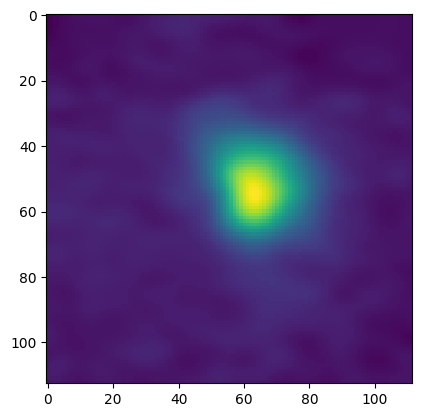

In [12]:
#To cut down into spatial and spectral regions of interest

#Frequency in Hz will be visible in ds9 as you toggle between images in cube
sub_cube_slab = cube.spectral_slab(2.3053e+11 *u.Hz, 2.30536e+11 *u.Hz)


#Also in ds9 alma data will include on-sky RA and Dec, which you can get in degrees by 
#changing WCS options
lat_range = [-33.7720066,-33.7735693] * u.deg
lon_range = [127.1686176,127.1704721] * u.deg

sub_cube_slab = cube.subcube(xlo = lon_range[0],xhi=lon_range[1],ylo=lat_range[0],yhi=lat_range[1])


subcubearray = np.array(sub_cube_slab)

#This allows you to quickly check images in cube
sub_cube_slab[5,:,:].quicklook()

In [13]:
#Write your subcube to a file
sub_cube_slab.write('fits/ATPyxSubCubeDemo.fits', format='fits',overwrite=True)  

## Moment Maps

In [14]:
#Using bettermoments, preparing cube for moment map creation

data, velax = bm.load_cube('fits/ATPyxSubCubeDemo.fits')


#You can 'smooth' the line data out over the spectral range, in this case basically no smoothing though
#see https://bettermoments.readthedocs.io/en/latest/ for more on this
smoothed_data = bm.smooth_data(data=data,smooth=1,polyorder=0)
rms = bm.estimate_RMS(data=data, N=1)
rms_smoothed = bm.estimate_RMS(data=smoothed_data, N=1)

print('RMS = {:.1f} mJy/beam (original)'.format(rms * 1e3))
print('RMS = {:.1f} mJy/beam (smoothed)'.format(rms_smoothed * 1e3))

RMS = 5.1 mJy/beam (original)
RMS = 5.1 mJy/beam (smoothed)


In [33]:
#making masks
#in this case, the masks do nothing but you can tweak this code to provide them

user_mask = bm.get_user_mask(data=data, user_mask_path=None)

#intensity threshold-based mask
threshold_mask=bm.get_threshold_mask(data=data,
                                    clip=1,
                                    smooth_threshold_mask=0.0)

#this masks out unwanted channels, but we already did this with spectral-cube
channel_mask = bm.get_channel_mask(data=data,
                                   firstchannel=1,
                                   lastchannel=-1)

#combines all masks
mask = bm.get_combined_mask(user_mask=user_mask,
                            threshold_mask=threshold_mask,
                            channel_mask=channel_mask,
                            combine='and')
masked_data = data * mask

#shows bettermoments collapse methods
bm.available_collapse_methods()

Available methods are:

	 zeroth       (integrated intensity)
	 first        (intensity weighted average velocity)
	 second       (intensity weighted velocity dispersion)
	 eighth       (peak intensity)
	 ninth        (velocity channel of peak intensity)
	 maximum      (both collapse_eighth and collapse_ninth)
	 quadratic    (quadratic fit to peak intensity)
	 width        (effective width for a Gaussian profile)
	 percentiles  (intesity weighted percentiles)
	 gaussian     (gaussian fit)
	 gaussthick   (gaussian with optically thick core fit)
	 gausshermite (gaussian-hermite expansion fit)
	 doublegauss  (double gaussian fit)

Call the function with `collapse_{method_name}`.


In [34]:
#Moment 0 Map (Total Intensity) - gives a good combined image of all CO gas emission
moments = bm.collapse_zeroth(velax=velax, data=masked_data, rms=rms)
bm.save_to_FITS(moments=moments, method='zeroth', 
                path='fits/ATPyxSubCubeDemo.fits')

Text(0, 0.5, 'Offset (arcsec)')

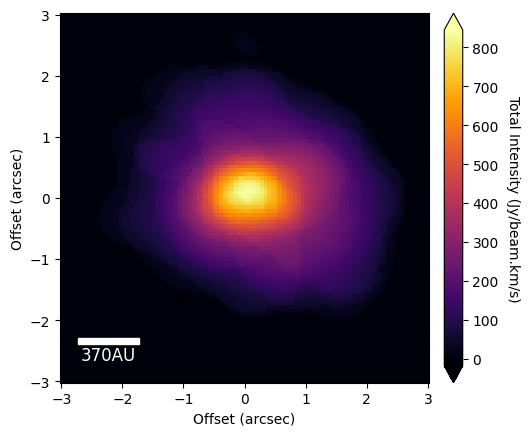

In [35]:
import matplotlib.font_manager as fm
fontprops = fm.FontProperties(size=12)

imgsize=100

momentzero = fits.open('fits/ATPyxSubCubeDemo_M0.fits')[0].data
momentzero = np.array(Cutout2D(momentzero,
                                (len(momentzero[0])/2,len(momentzero)/2),
                                (imgsize,imgsize)).data)
fig,ax = plt.subplots(1,1) 


im = ax.imshow(momentzero,
          cmap='inferno',
          extent=[0.06048*imgsize/2,-0.06048*imgsize/2,-0.06048*imgsize/2,0.06048*imgsize/2],origin='lower',zorder=-9)
cb = plt.colorbar(im, pad=0.03, extend='both', format='%.0f')
cb.set_label(r'Total Intensity (Jy/beam.km/s)',
                     rotation=270, labelpad=15)

scalebar = AnchoredSizeBar(ax.transData,
                           1, '370AU', 'lower left', 
                           pad=1,
                           color='white',
                           frameon=False,
                           size_vertical=0.1,
                           fontproperties=fontprops
                           )
ax.add_artist(scalebar)
ax.invert_xaxis()

ax.set_xlabel('Offset (arcsec)')
ax.set_ylabel('Offset (arcsec)')

In [36]:
#Moment 1 Map (Intensity-weighted Velocity) 
#This is your velocity map - shows redshifted and blueshifted regions
#VERY useful for getting disk position angle
#Major axis is perpendicular to line dividing red- and blue-shifted regions
moments = bm.collapse_first(velax=velax, data=masked_data, rms=rms)
bm.save_to_FITS(moments=moments, method='first', 
                path='fits/ATPyxSubCubeDemo.fits')

Text(0, 0.5, 'Offset (arcsec)')

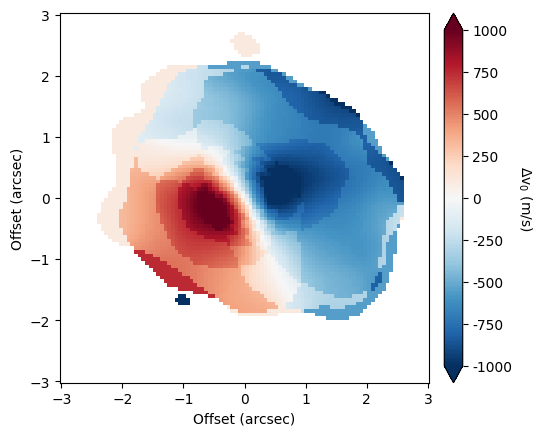

In [37]:
import matplotlib.font_manager as fm
fontprops = fm.FontProperties(size=12)

imgsize=100

momentone = fits.open('fits/ATPyxSubCubeDemo_M1.fits')[0].data
momentone = np.array(Cutout2D(momentone,
                                (len(momentone[0])/2,len(momentone)/2),
                                (imgsize,imgsize)).data)
fig,ax = plt.subplots(1,1) 


im = ax.imshow(momentone+12000,
          cmap='RdBu_r',
          extent=[0.06048*imgsize/2,-0.06048*imgsize/2,-0.06048*imgsize/2,0.06048*imgsize/2],origin='lower',
               vmin=-1000,vmax=1000,
               zorder=-9)
cb = plt.colorbar(im, pad=0.03, extend='both', format='%.0f')
cb.set_label(r'$\Delta$v$_0$ (m/s)',
                     rotation=270, labelpad=15)

scalebar = AnchoredSizeBar(ax.transData,
                           1, '370AU', 'lower left', 
                           pad=1,
                           color='white',
                           frameon=False,
                           size_vertical=0.1,
                           fontproperties=fontprops
                           )
ax.add_artist(scalebar)
ax.invert_xaxis()

ax.set_xlabel('Offset (arcsec)')
ax.set_ylabel('Offset (arcsec)')

In [39]:
#Moment 8 Map (Peak Intensity) - like moment 0, but better :)
moments = bm.collapse_eighth(velax=velax, data=masked_data, rms=rms)
bm.save_to_FITS(moments=moments, method='eighth', 
                path='fits/ATPyxSubCubeDemo.fits')

Text(0, 0.5, 'Offset (arcsec)')

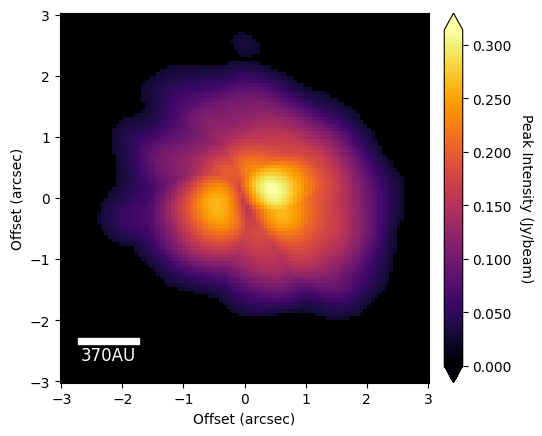

In [40]:
import matplotlib.font_manager as fm
fontprops = fm.FontProperties(size=12)

imgsize=100

momenteight = fits.open('fits/ATPyxSubCubeDemo_M8.fits')[0].data
momenteight = np.array(Cutout2D(momenteight,
                                (len(momenteight[0])/2,len(momenteight)/2),
                                (imgsize,imgsize)).data)
fig,ax = plt.subplots(1,1) 


im = ax.imshow(momenteight,
          cmap='inferno',
          extent=[0.06048*imgsize/2,-0.06048*imgsize/2,-0.06048*imgsize/2,0.06048*imgsize/2],origin='lower',zorder=-9)
cb = plt.colorbar(im, pad=0.03, extend='both', format='%.3f')
cb.set_label(r'Peak Intensity (Jy/beam)',
                     rotation=270, labelpad=15)

scalebar = AnchoredSizeBar(ax.transData,
                           1, '370AU', 'lower left', 
                           pad=1,
                           color='white',
                           frameon=False,
                           size_vertical=0.1,
                           fontproperties=fontprops
                           )
ax.add_artist(scalebar)
ax.invert_xaxis()

ax.set_xlabel('Offset (arcsec)')
ax.set_ylabel('Offset (arcsec)')

## Eddy

In [43]:
#Best option for eddy is gaussian, however this takes a LONG time to generate
#Do a gaussian when you are confident that your cube is good
#For this example, we use a quadratic method as it's quick and provides similar data
moments = bm.collapse_quadratic(velax=velax, data=masked_data, rms=rms)
bm.save_to_FITS(moments=moments, method='quadratic', 
                path='fits/ATPyxSubCubeDemo.fits')

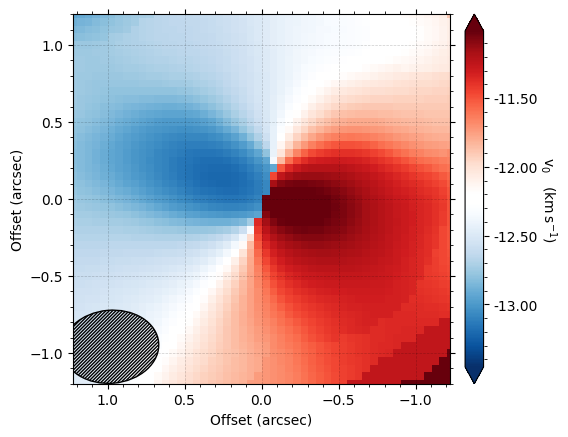

In [54]:
#Load cube into eddy - check my imports if confused by the appearance of 'rotationmap' in this section

#for quadratic the extensions are _v0 and _dv0
#for a gaussian the extensions will be _gv0 and _dgv0
cube = rotationmap(path='fits/ATPyxSubCubeDemo_v0.fits',
                   uncertainty='fits/ATPyxSubCubeDemo_dv0.fits',
                   #downsample='beam', #if your beam size is large- don't downsample, it will look shit
                   FOV=2.4
                  )

#eddy function that shows your rotationmap
#you can tweak the FOV parameter to zoom in and avoid bad regions
#also this shows you your beam size - fun!
cube.plot_data()

In [52]:
#You can set your priors here if you have some image parameters that are known and you
#want to constrain the fit somewhat

cube.set_prior('vlsr',[-12000,5000],'gaussian')
cube.set_prior('z0',[0.44,0.1],'gaussian')
cube.set_prior('x0',[-0.0296,0.005],'gaussian')
cube.set_prior('y0',[0.18,0.05],'gaussian')

Assuming:
	p0 = [x0, y0, PA, mstar, vlsr, z0, psi, r_taper, q_taper].


100%|███████████████████████████████████████| 2500/2500 [03:39<00:00, 11.39it/s]


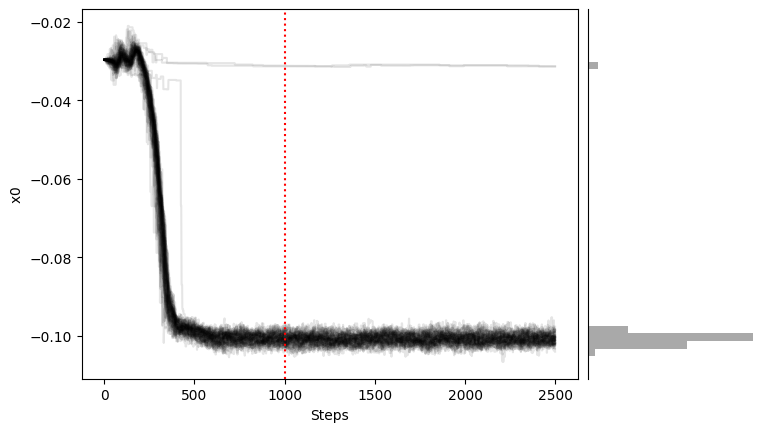

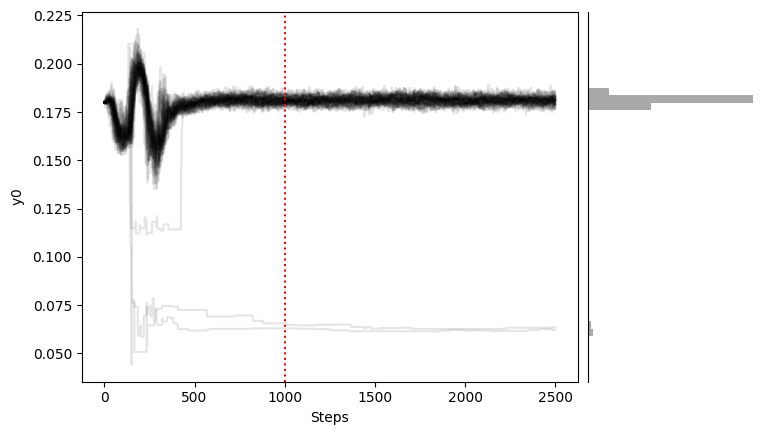

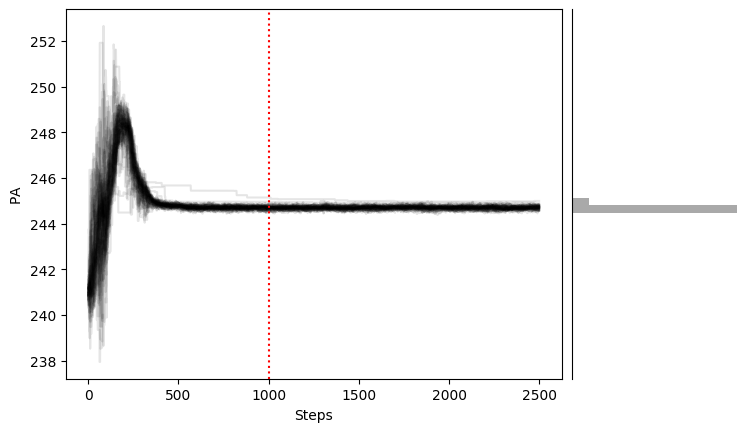

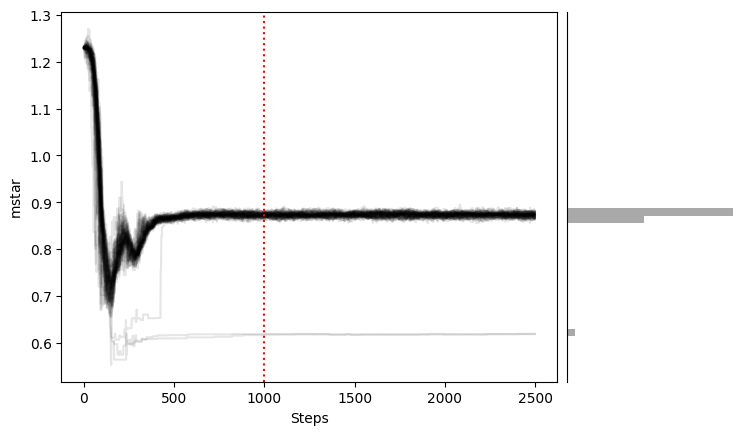

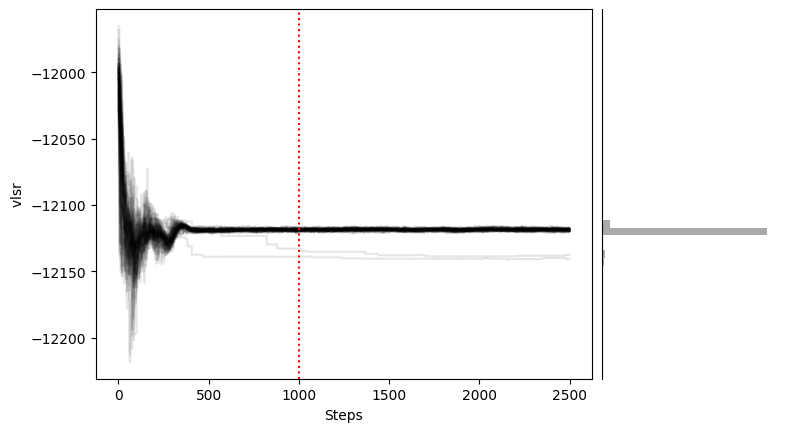

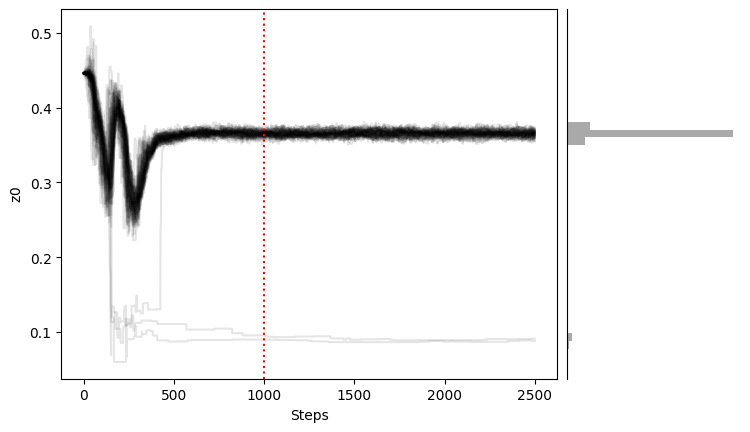

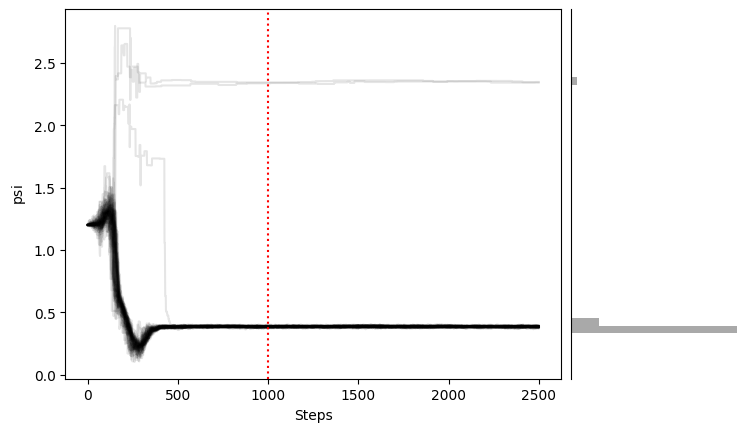

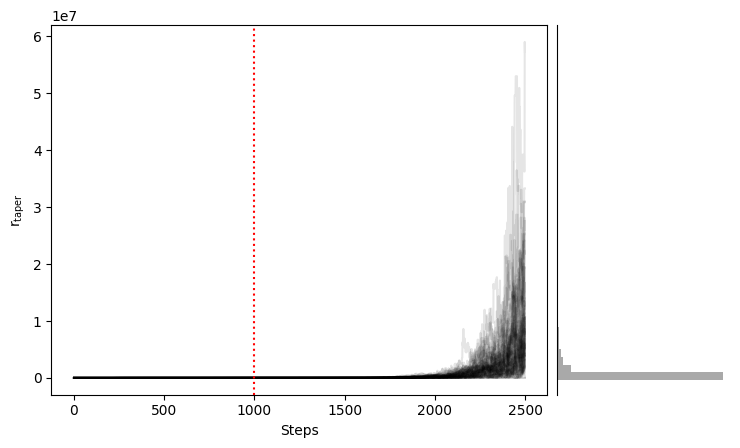

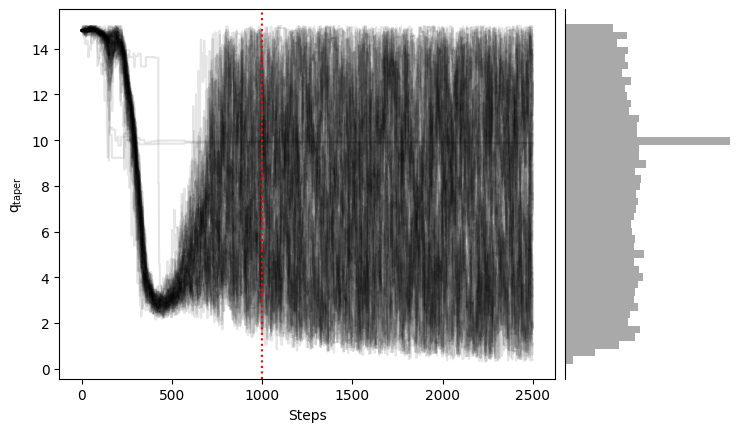

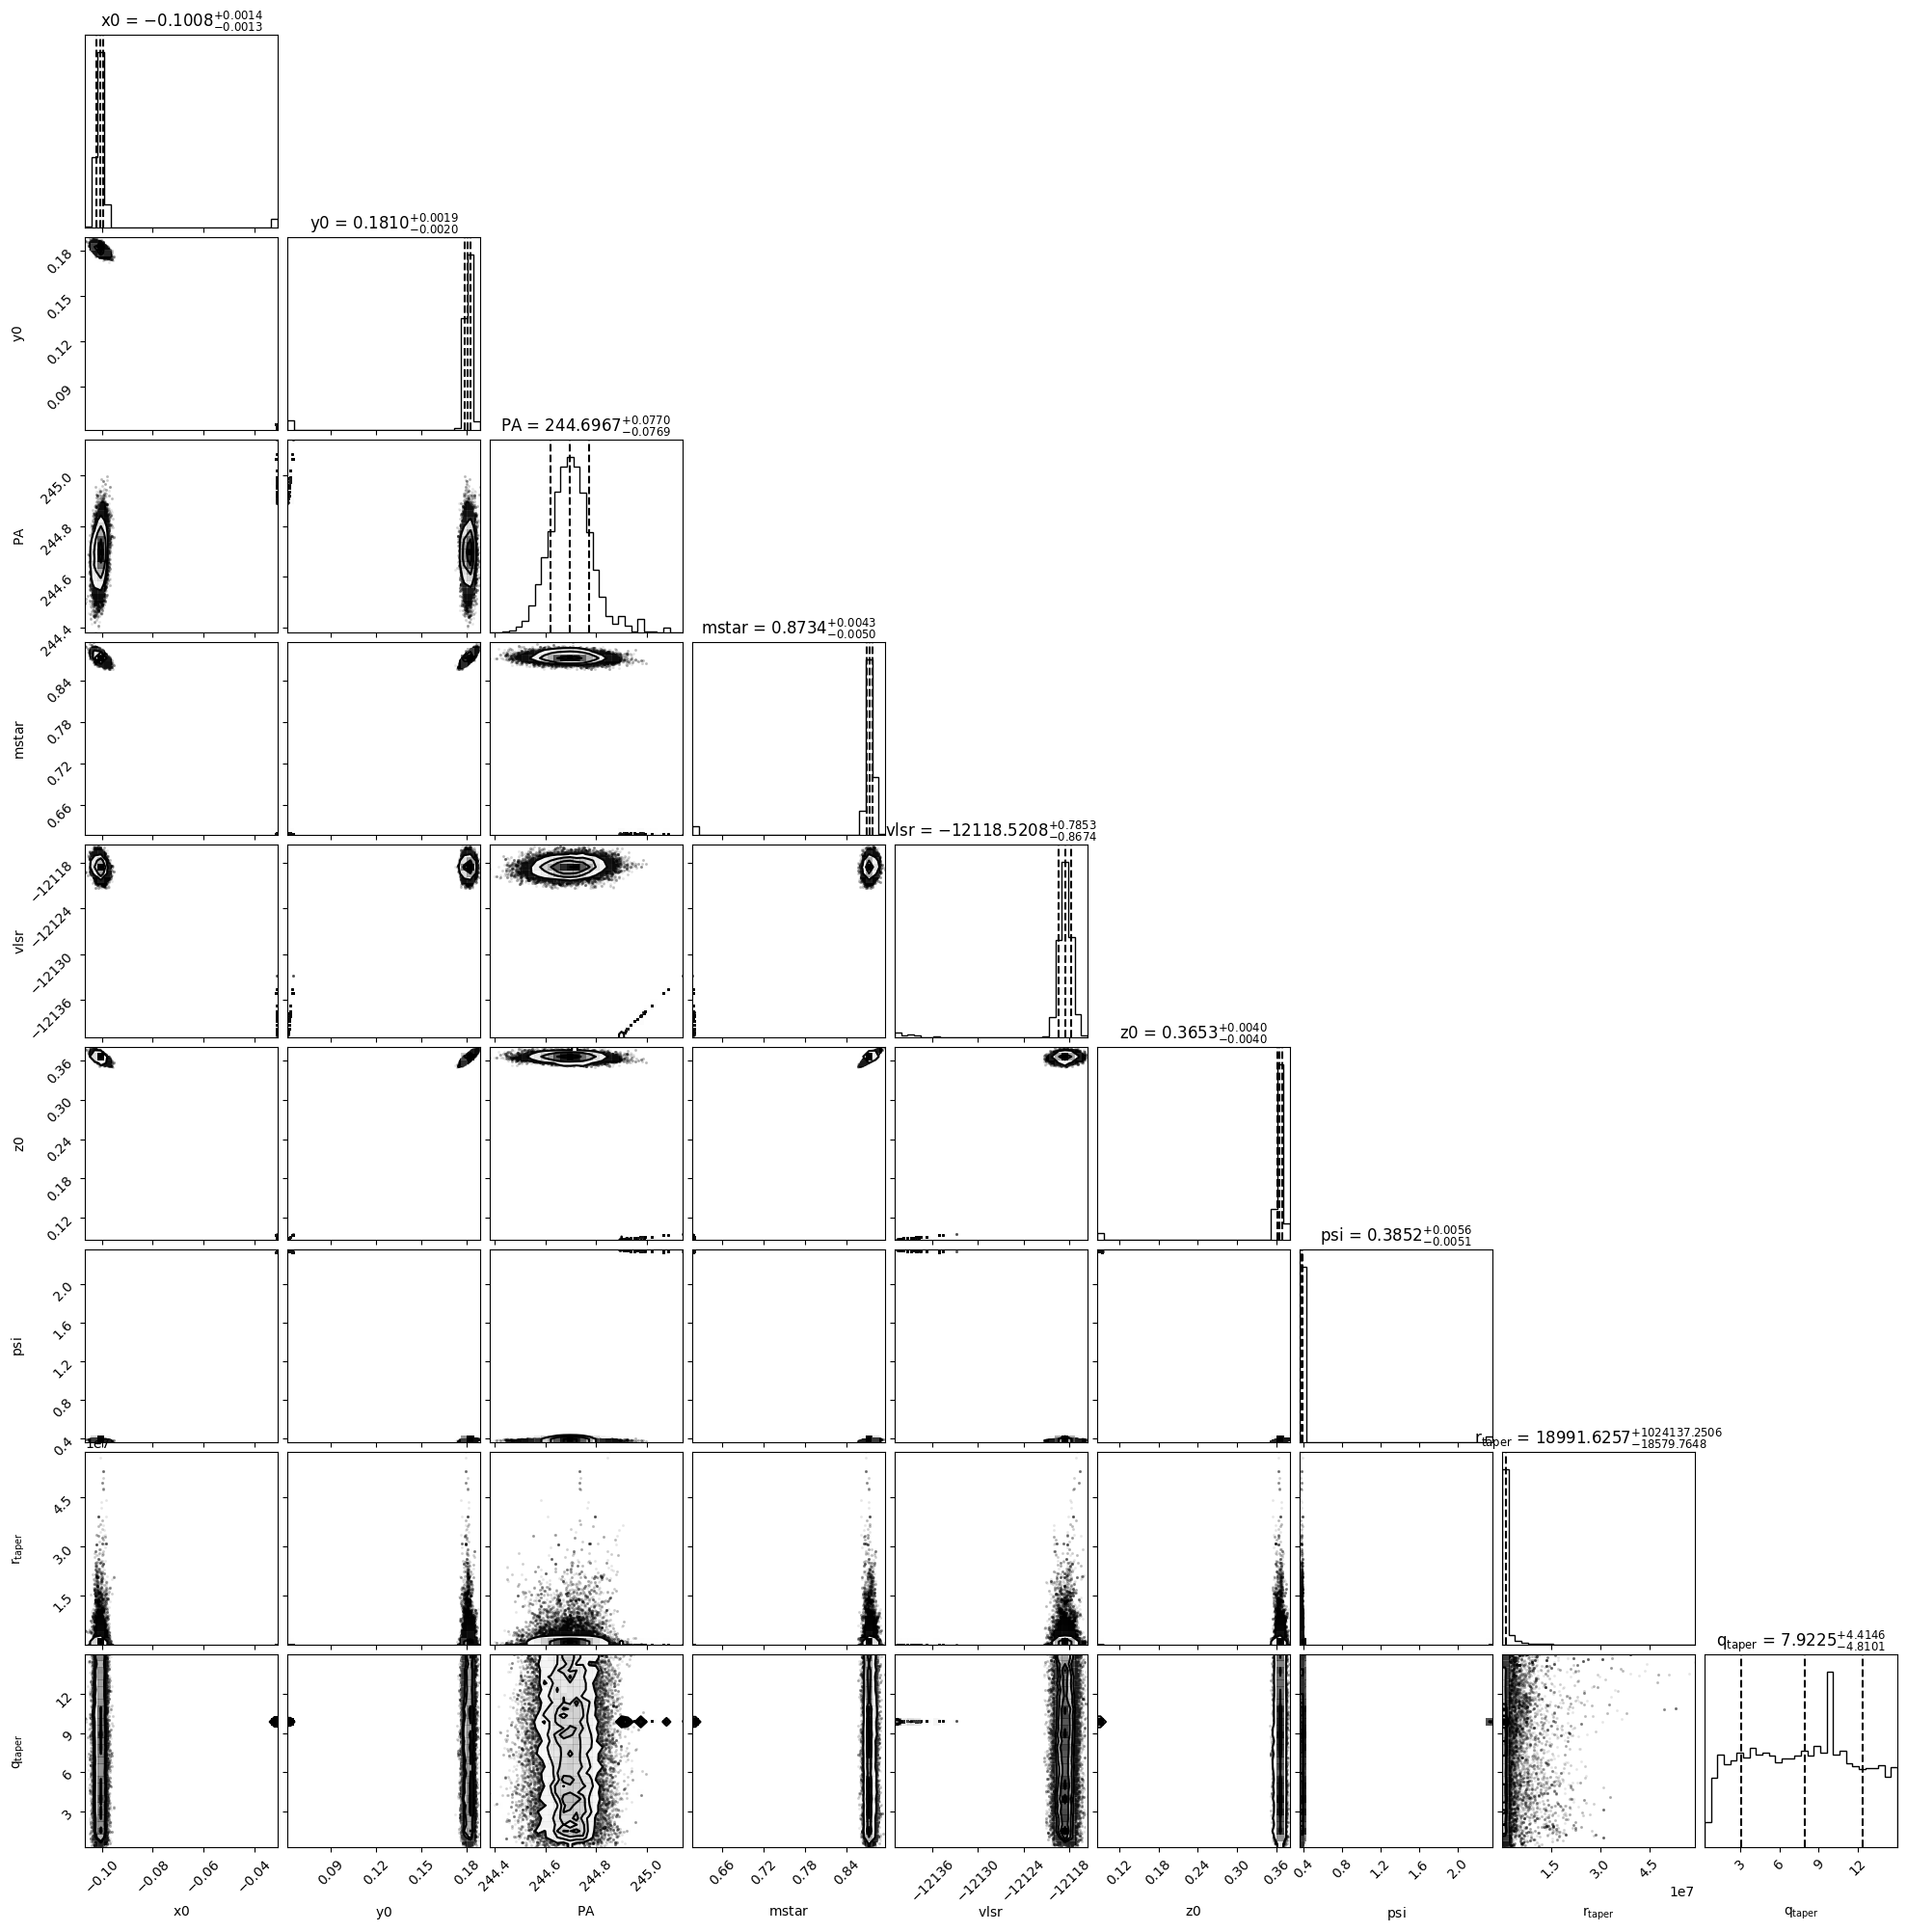

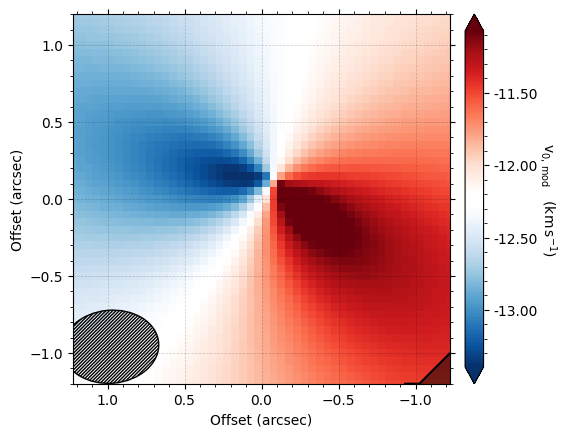

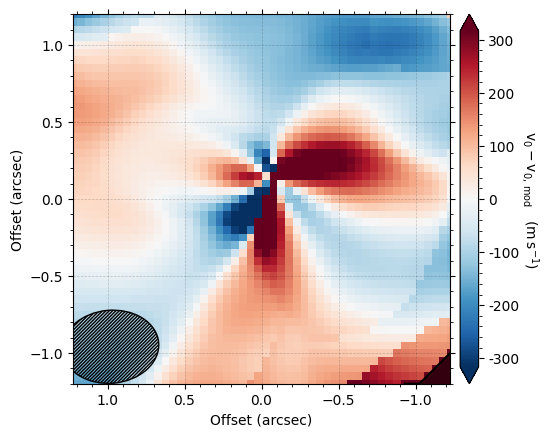

In [53]:
#Making an eddy model!

#These are your basic parameters, initialized here...

params = {}
params['x0'] = 0
params['y0'] = 1
params['PA'] = 2
params['mstar'] = 3
params['vlsr'] = 4


#...and given values here
p0 = [-0.0296, 0.18, 241., 1.23, -12.0e3]

#these parameters are fixed and do not change with the fitting process
#in my project I knew the stellar mass but not inclination, so I changed inclination each time and
#based the final accepted inclination off whatever input inclination produced a fit with an accurate
#stellar mass
params['inc'] = 42.5
params['dist'] = 370.0


#Elevated emission surface parameters.
#These you use when modelling a 3d disk, the above parameters apply to a 2d disk
#z0 = scale height at 1''
#psi = flaring power
#r_taper and q_taper other shaping parameters
#https://eddy.readthedocs.io/en/latest/tutorials/tutorial_2.html for equation and description

params['z0'] = 5
params['psi'] = 6
params['r_taper'] = 7
params['q_taper'] = 8

#Range of velocities for fit

params['v_max'] = -10.0e3
params['v_min'] = -14.0e3

#adding values for elevated surface params
p0 += [0.446, 1.2,2.9,14.8
      ]

#Running fit! Can vary number of walkers, steps and iterations
#More walkers = slightly better fit, longer run time 
#--> recommend starting with 16 or 32, then 64 when confident in quality of fit with input params
#Burnin refers to steps in which fitting occurs that do not factor into final outputs
#--> this gives the model a number of steps to flail around until it finds the right fit

samples = cube.fit_map(p0=p0, params=params, optimize=False,
                           nwalkers=64, nburnin=1000, nsteps=1500,niter=1
                           )

# As you can see below, this is not a good fit 
#- a good one may take time to get and need multiple iterations
# In my case I used a gaussian input, which probably helps
# You may spend a long time on this bit ;)

# mm Dust Continuum Emission Data

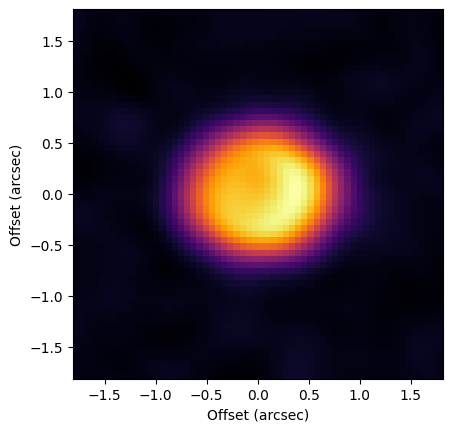

In [60]:
#Dust continuum image will be a single image

continuum = fits.open('NewALMAData/AT_Pyx_SB_final_rob0.5_im.fits')[0].data[0][0]

continuum = Cutout2D(continuum,(len(continuum[1])/2-2,len(continuum[0])/2),(60,60))

fig, ax = plt.subplots()

positions = [(0.1, 0)]
m=1.2
ap = aperture.EllipticalAperture(positions, a=1*m,b=0.8*m)



#ap_patches = ap.plot(color='white', lw=2,label='Photometry aperture')

Flux = aperture.ApertureStats(continuum.data, ap).sum


    
im = ax.imshow(continuum.data,
          cmap='inferno',
          extent=[0.0604*30,-0.0604*30,-0.0604*30,0.0604*30],origin='lower',zorder=-9)
#cb = plt.colorbar(im, pad=0.03, extend='both', format='%.3f')
#cb.set_label(r'Peak Intensity (Jy/beam)',
#                     rotation=270, labelpad=15)
#ax.plot(np.linspace(-1.5,1.5,20),np.zeros(20),linestyle='dashed',color='red')
ax.set_xlabel('Offset (arcsec)')
ax.set_ylabel('Offset (arcsec)')
ax.invert_xaxis()

The easiest way to calculate dust mass from one of these images actually starts with ds9

Open continuum image in ds9

Region -> shape -> ellipse

Edit -> region  then draw ellipse fitting over continuum emission

Region -> get information -> analyse -> statistics

Get sum of all flux from here

This flux will be in the form Jy/beam :)))

To convert from Jy/beam to Jy - divide sum flux by $$\Omega_b = \frac{\pi}{4\ln 2} \times b_{\text{maj}} \times b_{\text{min}}$$ with b referring to beam major and minor axes - these you can find in the file header as bmaj and bmin, viewable in ds9

In [61]:
#Christian's code for getting disk dust mass from continuum integrated flux
#Dust mass:Gas mass = 1:100
#So multiply dust mass by 100 to get total disk mass!

import math
def calculate_dust_mass_from_fnu(fnu,dfnu,d,dd,nu):
    
    #assuming standard law for opacity: 2.3 cm2/g * (nu/230 GHz)**0.4
    #assuming fixed dust temperatre of 20 K
    #M_dust = d**2 * F_nu / K_nu * B_nu(T(r)) with K_nu opacity, B_nu planck function
    # d input in parsec, fnu input in mJy, nu input in GHz
    
    #Step 1 calculate opacity:
        
    k_nu = 2.3 * (nu/230)**0.4 #cm2/g
    
    #Step 2 calculate planck function:
    T = 20
    h_planck =6.62607004e-34 #m2 kg / s 
    k_boltz = 1.38064852e-23 #m2 kg s-2 K-1
    c_light = 299792458 #m / s
    nu = nu * 1e9 # from Ghz to Hz
    
    B_nu = ((2 * h_planck * nu**3)/c_light**2) / (math.exp(nu*h_planck/(k_boltz * T))-1) #  W·sr−1·m−2·Hz−1
    #print B_nu
    
    #Step 3 calculate dust mass:
    # 1 Jy = 1e-26 W / (m2 Hz)
    # these are the units with intended input:
    # pc * (1e-29 W/(m2 Hz)) / (cm^2/g * W/(m2 * Hz)) = pc / (cm²/g) = pc * g/cm^2
    # so need to convert distance to cm and then result will be in grams    
    
    d = d * 3.08567758e18
    
    M_dust = (d**2) * fnu*1e-29 / (k_nu * B_nu) # in grams 
    M_dust = M_dust * 1.67442764e-28 # in earth masses
    
    d_Mdust = math.sqrt(((2 * fnu*1e-29 / (k_nu * B_nu)) * (d * dd))**2 + ((d**2) * dfnu*1e-29 / (k_nu * B_nu))**2)
    d_Mdust = d_Mdust * 1.67442764e-28 # in earth masses
    
    print(M_dust)
    print(d_Mdust)   
    
    return

